# T3 : Fine-tuning des modèles · Jour 3

> ⚠️ **Ce notebook ne s'exécute pas en entier.** Les cellules marquées **⛔ ne pas exécuter**
> téléchargent un modèle (~270 Mo) et lancent un entraînement qui durerait plusieurs heures
> sur CPU. Lisez-les, ne les lancez pas.
>
> Les cellules **sans marqueur** s'exécutent librement (visualisations matplotlib, calculs Python).

## 🎯 Objectifs

À la fin de ce notebook, vous savez :

1. Expliquer la différence entre **pré-entraînement**, **Supervised Fine-Tuning (SFT)** et **Direct Preference Optimization (DPO)**
2. Comprendre pourquoi **Low-Rank Adaptation (LoRA)** réduit les paramètres entraînables de plus de 99 % *pour une perte de qualité faible sur les tâches proches du domaine de pré-entraînement*
3. **Préparer un dataset** au format attendu par `SFTTrainer` (bibliothèque HuggingFace TRL)
4. Lire une **configuration Low-Rank Adaptation (LoRA)** et ajuster les hyperparamètres clés (`r`, `lora_alpha`)
5. **Estimer le coût** d'un fine-tuning avant de le lancer

## 🗺️ Plan

| Partie | Sujet |
|---|---|
| **1** | Fondations, quand et pourquoi fine-tuner |
| **2** | Low-Rank Adaptation (LoRA), adapter sans recalciner |
| **3** | Mise en œuvre, SmolLM2-135M + TRL + PEFT |

## 📖 Glossaire express

| Terme | En clair |
|---|---|
| **SFT** | *Supervised Fine-Tuning*, montrer des exemples de bonnes réponses au modèle |
| **RLHF** | *Reinforcement Learning from Human Feedback*, noter les réponses, puis optimiser en conséquence |
| **DPO** | *Direct Preference Optimization*, alternative à RLHF : optimise directement sur les préférences, sans boucle de RL ni modèle de récompense séparé |
| **LoRA** | *Low-Rank Adaptation*, ajouter deux petites matrices B·A plutôt que retoucher tout W |
| **PEFT** | *Parameter-Efficient Fine-Tuning*, famille de méthodes pour fine-tuner sans tout recalciner |
| **TRL** | *Transformer Reinforcement Learning*, bibliothèque HuggingFace qui fournit `SFTTrainer` |
| **Rang r** | Taille des matrices LoRA, plus r est grand, plus le modèle peut s'adapter |
| **SmolLM2** | Famille de petits modèles open-weight HuggingFace (135M à 1,7B paramètres) |

## 🛠️ Prérequis, dépendances

Les **visualisations** n'ont pas de dépendances supplémentaires (matplotlib est déjà là depuis J1).

Pour **exécuter le fine-tuning** sur votre propre machine après la formation :

```powershell
uv sync --extra finetuning
```

> ⚠️ **Piège.** `peft` et `trl` évoluent vite et **cassent régulièrement leur API**.
> Deux exemples visibles dans ce notebook même : `SFTConfig.max_seq_length` a été
> **supprimé** en `trl 0.20`, et `from_pretrained(torch_dtype=...)` est déprécié au
> profit de `dtype=` depuis `transformers 4.56`.
>
> Épinglez donc, mais épinglez **la pile entière**. Un pin sur `trl` seul ne sert à rien :
> `trl` déclare `transformers>=…` sans borne haute et laisse le résolveur prendre la
> dernière version. Le groupe `finetuning` du `pyproject.toml` fixe les six paquets ensemble.

In [1]:
# --- bibliothèques de visualisation (pas de GPU requis) ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # pour les boîtes arrondies (FancyBboxPatch)
from rich.table import Table           # tableau formaté avec colonnes et couleurs
from rich.console import Console       # moteur d'affichage Rich (fonctionne dans Jupyter)

# style global des graphiques : supprime les bordures parasites (top/right)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print("✅ Bibliothèques de visualisation chargées")

✅ Bibliothèques de visualisation chargées


---
## Partie 1, Fondations

**Pourquoi fine-tuner ?** Un LLM pré-entraîné, c'est un peu comme un expert généraliste
fraîchement sorti d'une grande école : brillant, mais pas adapté à *votre* contexte.

- ❌ Il ne connaît **pas vos données internes** (votre base de connaissances, vos produits, vos clients)
- ❌ Il ne parle **pas votre langage** (ton de marque, jargon métier, format de sortie attendu)
- ❌ Il ne respecte **pas vos règles spécifiques** ("ne jamais mentionner X", "toujours répondre en JSON")

Quatre leviers existent pour corriger ça, du moins invasif au plus coûteux.
**Règle d'or : partez de gauche, n'avancez que si le précédent ne suffit pas.**

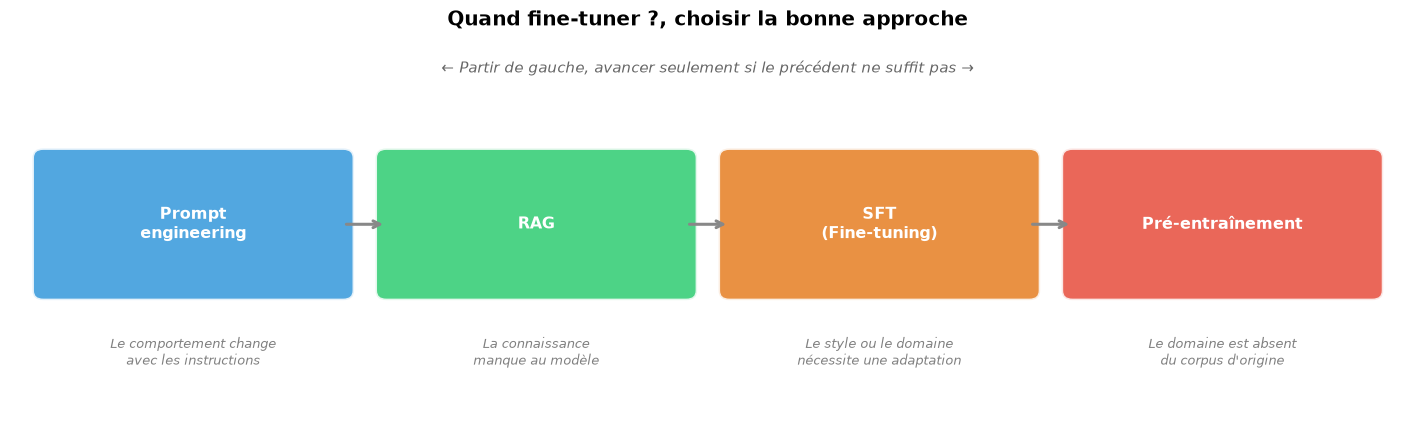

In [2]:
# Diagramme de décision : quand utiliser chaque approche d'adaptation
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.axis('off')  # on dessine manuellement, pas de système de coordonnées automatique
ax.set_title("Quand fine-tuner ?, choisir la bonne approche", fontsize=13, fontweight='bold')

# (label, couleur, position x, raison affichée sous la boîte)
methodes = [
    ("Prompt\nengineering", "#3498db", 0.3,  "Le comportement change\navec les instructions"),
    ("RAG",                  "#2ecc71", 3.5,  "La connaissance\nmanque au modèle"),
    ("SFT\n(Fine-tuning)",  "#e67e22", 6.7,  "Le style ou le domaine\nnécessite une adaptation"),
    ("Pré-entraînement",     "#e74c3c", 9.9,  "Le domaine est absent\ndu corpus d'origine"),
]

# Dessine chaque boîte arrondie avec son libellé et la raison d'usage en dessous
for nom, couleur, x, raison in methodes:
    rect = mpatches.FancyBboxPatch(
        (x, 1.3), 2.8, 1.4,
        boxstyle="round,pad=0.1", facecolor=couleur, alpha=0.85,
        edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x + 1.4, 2.0, nom, ha='center', va='center',
            fontsize=10.5, fontweight='bold', color='white')
    ax.text(x + 1.4, 0.65, raison, ha='center', va='center',
            fontsize=8.5, color='gray', style='italic')

# Flèches de gauche à droite entre chaque boîte
for x_arr in [3.1, 6.3, 9.5]:
    ax.annotate("", xy=(x_arr + 0.4, 2.0), xytext=(x_arr, 2.0),
                arrowprops=dict(arrowstyle="->", color='#888', lw=2))

# Légende de navigation
ax.text(6.5, 3.6,
        "← Partir de gauche, avancer seulement si le précédent ne suffit pas →",
        ha='center', fontsize=10, color='#666', style='italic')
plt.tight_layout()
plt.show()

> 🎯 **À retenir.** Le fine-tuning est souvent la *dernière* réponse, pas la première :
>
> - ⚡ Un **bon prompt** → quelques minutes, et il résout déjà la majorité des cas
> - 📚 Un **Retrieval-Augmented Generation (RAG) bien conçu** → quelques jours, et il couvre l'essentiel du reste quand le problème est un manque de connaissance
> - 🔧 Un **Supervised Fine-Tuning (SFT)** → plusieurs semaines et des données annotées, pour ce qui reste : le style, le format, les comportements systématiques
>
> *Si vous n'avez pas encore essayé le RAG : arrêtez-vous là d'abord (voir T2 de ce cours).*

### 1.3, Format des données pour le Supervised Fine-Tuning (SFT)

**L'analogie parfaite :** le Supervised Fine-Tuning (SFT), c'est comme former un stagiaire.
Vous lui montrez des exemples de **bonnes réponses** à des questions, il apprend à
*reproduire ce style et ce niveau de qualité* sur de nouvelles questions.

**Le format est simple :** une liste de conversations avec des rôles.

| Rôle | Quand l'utiliser |
|---|---|
| `user` | La question ou l'instruction |
| `assistant` | La réponse *idéale* que vous voulez que le modèle apprenne |
| `system` | (optionnel) Les règles générales du modèle |

**3 ingrédients d'un bon dataset Supervised Fine-Tuning (SFT) :**
- 🎯 **Diversité** : couvrir les vrais cas d'usage, pas juste les cas faciles
- ✍️ **Qualité** : mieux vaut 100 exemples parfaits que 10 000 médiocres
- ⚖️ **Équilibre** : ne pas surreprésenter certains types de questions

Cette cellule **s'exécute librement** : elle ne crée que des structures Python en mémoire.

In [3]:
# Exemples de dataset SFT sur les vins du Jura, même corpus que T2 RAG.
# Format : liste de dicts avec une clé "messages" (identique à l'API Chat).
# Cette cellule s'exécute librement : elle ne crée que des structures Python.
EXEMPLES_SFT = [
    {"messages": [
        {"role": "user",      "content": "Qu'est-ce que le vin jaune du Jura ?"},
        {"role": "assistant", "content": (
            "Le vin jaune est un vin blanc d'exception produit dans le Jura à partir "
            "du cépage Savagnin. Vinifié sans ouillage dans des fûts pendant au moins "
            "six ans et trois mois sous un voile de levures, il développe des arômes "
            "de noix, de curry et d'épices. Il est vendu dans le clavelin, une bouteille "
            "de 62 cl propre à l'appellation."
        )},
    ]},
    {"messages": [
        {"role": "user",      "content": "Qu'est-ce que le ploussard ?"},
        {"role": "assistant", "content": (
            "Le Ploussard (ou Poulsard) est un cépage rouge léger typique du Jura, "
            "cultivé principalement à Pupillin. Il donne des vins pâles aux tanins "
            "soyeux avec des arômes de fruits rouges frais. C'est l'un des rares "
            "cépages rouges à maturité précoce du Jura."
        )},
    ]},
    {"messages": [
        {"role": "user",      "content": "Qu'est-ce que le macvin du Jura ?"},
        {"role": "assistant", "content": (
            "Le Macvin du Jura est un vin de liqueur AOC produit en ajoutant "
            "de l'eau-de-vie de marc du Jura dans du moût de raisin non fermenté. "
            "Il se décline en blanc, rosé et rouge, et se déguste généralement "
            "en apéritif ou en accord avec le fromage Comté."
        )},
    ]},
]

# Affichage d'un aperçu de chaque exemple (tronqué pour la lisibilité)
for i, ex in enumerate(EXEMPLES_SFT, 1):
    user_msg = ex["messages"][0]["content"]
    asst_msg = ex["messages"][1]["content"][:70]
    print(f"Ex {i} | user : {user_msg[:55]}...")
    print(f"       | asst : {asst_msg}...\n")
print(f"✅ {len(EXEMPLES_SFT)} exemples formatés")

Ex 1 | user : Qu'est-ce que le vin jaune du Jura ?...
       | asst : Le vin jaune est un vin blanc d'exception produit dans le Jura à parti...

Ex 2 | user : Qu'est-ce que le ploussard ?...
       | asst : Le Ploussard (ou Poulsard) est un cépage rouge léger typique du Jura, ...

Ex 3 | user : Qu'est-ce que le macvin du Jura ?...
       | asst : Le Macvin du Jura est un vin de liqueur AOC produit en ajoutant de l'e...

✅ 3 exemples formatés


> ⚠️ **Piège : la quantité ne remplace pas la qualité.**
> Avec seulement 3 exemples, le modèle mémorise sans vraiment apprendre.
>
> - **≥ 300 exemples** → un Supervised Fine-Tuning (SFT) qui commence à être utile
> - **≥ 1 000 exemples** → des comportements stables et généralisables
> - **Qualité >>> Quantité** : toujours. Un mauvais exemple coûte plus qu'une absence d'exemple.

> 🎯 **À retenir.** Le format `messages` est identique à l'API Chat : vos **logs de
> conversations** fournissent donc gratuitement le format et les vraies questions de vos
> utilisateurs.
>
> ⚠️ En revanche les réponses qu'ils contiennent sont celles de **votre modèle actuel**,
> pas les réponses idéales. Les réutiliser telles quelles revient à entraîner le modèle
> sur ses propres erreurs. Elles doivent être filtrées, corrigées ou réécrites.

### 1.4, Reinforcement Learning from Human Feedback (RLHF) et Direct Preference Optimization (DPO) : aligner le comportement

**Pourquoi ne pas s'arrêter au Supervised Fine-Tuning (SFT) ?**
Le SFT apprend *quoi* dire. Mais parfois le modèle :
- 🤥 **Hallucine avec confiance** : invente des faits avec un ton assuré
- 📏 **Répond trop long / trop court** : sans calibrer selon le besoin
- 🚫 **N'est pas honnête** sur ses limites ("je ne sais pas" est parfois la bonne réponse)

L'**alignement** lui apprend *comment bien se comporter*. Deux grandes approches :

---

**🔴 Reinforcement Learning from Human Feedback (RLHF)** : la méthode historique (InstructGPT, ChatGPT v1)
1. 🧑‍⚖️ Des humains comparent des paires de réponses : *"A est meilleure que B"*
2. 🤖 On entraîne un **modèle de récompense** qui imite ces préférences
3. 🔄 On optimise le LLM avec **Proximal Policy Optimization (PPO)** pour maximiser la récompense
→ *Très puissant, plus coûteux en calcul et en infrastructure (trois à quatre modèles en
mémoire), mais désormais outillé : TRL fournit `PPOTrainer` et `GRPOTrainer`*

---

**🟢 Direct Preference Optimization (DPO)** : la méthode moderne (Mistral, Llama 3 ; Qwen 2.5 en première étape seulement)
1. 👍👎 Mêmes données de préférence (paires chosen / rejected)
2. 🎯 On optimise **directement** avec une perte mathématique, *sans* boucle de Reinforcement Learning (RL)
   et **sans modèle de récompense à entraîner**. Il faut en revanche garder en mémoire un
   **modèle de référence gelé** (la politique issue du SFT) : deux modèles, contre quatre pour PPO.
→ *Code nettement plus simple. Résultats souvent comparables, Llama 3 a explicitement retenu
DPO, mais la littérature n'est pas unanime : plusieurs études de 2024 trouvent PPO supérieur
à budget d'annotation égal.*

---

> 🎯 **À retenir.** Pour la quasi-totalité des projets : **Supervised Fine-Tuning (SFT) d'abord,
> Direct Preference Optimization (DPO) ensuite si nécessaire**.
>
> 🙊 **Note honnête.** L'enjeu principal de l'alignement, c'est la **qualité des données de préférence**,
> pas la complexité du code. `SFTTrainer` + `DPOTrainer` de TRL s'enchaînent en quelques lignes.
>
> 🕰️ Et le pendule est reparti dans l'autre sens : depuis 2024-2025, le RL à récompense
> vérifiable (GRPO) domine l'entraînement des modèles de raisonnement. TRL fournit `GRPOTrainer`.

---
## Partie 2, Low-Rank Adaptation (LoRA) : adapter sans tout recalciner

**Le problème :** fine-tuner un LLM entier, c'est comme devoir **repeindre une cathédrale**
quand vous voulez juste changer la couleur d'une porte.

- 🏛️ **Le modèle** : des centaines de millions à des milliards de paramètres
- 🖌️ **Le fine-tuning classique** : mettre à jour *tous* ces paramètres + stocker leurs gradients
- 💥 **Le résultat** : des dizaines de Go de mémoire GPU nécessaires, souvent inaccessible

**Low-Rank Adaptation (LoRA) résout ça** avec une idée élégante :
*"Et si le changement dont le modèle a besoin était simple ? Deux petites matrices suffisent."*

### 2.1, Le problème de l'adaptation complète

**Pourquoi quantifier ?** Avant de comprendre la solution, comprenons le problème en chiffres.

Chaque paramètre du modèle coûte de la mémoire GPU :

- 📦 **Les poids** (float32) → 1 paramètre = **4 octets**
- 📉 **Les gradients** (un par poids, même précision) → **4 octets de plus**
- ⚙️ **L'optimiseur Adam** (deux états, moment et variance) → **8 octets de plus**
- 💰 **Total full fine-tuning** → **16 octets par paramètre**, hors activations

*Multipliez par 135 millions (SmolLM2) ou 7 milliards (Mistral)...*

In [4]:
# Calcul de l'empreinte mémoire GPU selon la taille du modèle.
# float32 : poids 4 o + gradients 4 o + 2 états Adam 8 o = 16 o par paramètre.
# Unité : gigaoctet décimal (1e9), la même que le graphique de la partie QLoRA.
modeles = [
    ("SmolLM2-135M",  135_000_000),
    ("SmolLM2-360M",  360_000_000),
    ("SmolLM2-1.7B",  1_700_000_000),
    ("Mistral 7B",    7_000_000_000),
]

# Construction du tableau Rich : chaque colonne a un style et une justification
table = Table(title="Empreinte mémoire GPU (float32 : poids + gradients + Adam)")
table.add_column("Modèle",                    style="cyan")
table.add_column("Modèle seul",               justify="right")
table.add_column("Poids + gradients + Adam",  justify="right")

# n * 4 = poids seuls (float32) ; n * 16 = poids + gradients + 2 états Adam
for label, n in modeles:
    table.add_row(label, f"{n * 4 / 1e9:.2f} Go", f"{n * 16 / 1e9:.2f} Go")

Console().print(table)
print("GPU T4 (Colab) : 16 Go  |  RTX 3090 : 24 Go  |  A100 : 80 Go")

  Empreinte mémoire GPU (float32 : poids + gradients +   
                          Adam)                          
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Modèle       ┃ Modèle seul ┃ Poids + gradients + Adam ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ SmolLM2-135M │     0.54 Go │                  2.16 Go │
│ SmolLM2-360M │     1.44 Go │                  5.76 Go │
│ SmolLM2-1.7B │     6.80 Go │                 27.20 Go │
│ Mistral 7B   │    28.00 Go │                112.00 Go │
└──────────────┴─────────────┴──────────────────────────┘

GPU T4 (Colab) : 16 Go  |  RTX 3090 : 24 Go  |  A100 : 80 Go


> 🎯 **À retenir.** La mémoire explose avec la taille du modèle :
>
> - SmolLM2-135M → **2,2 Go** (faisable sur un laptop haut de gamme)
> - Mistral 7B → **112 Go** → il faut deux A100 80 Go, soit de l'ordre de 3 à 8 $ de l'heure
>   chez la plupart des fournisseurs (un fine-tuning est un job de quelques heures, pas une location au mois)
>
> *C'est précisément le problème que Low-Rank Adaptation (LoRA) résout.*

### 2.2, Low-Rank Adaptation (LoRA) : la décomposition de rang faible

**L'intuition en une phrase :**
> *"Le changement dont le modèle a besoin est souvent 'simple'. Deux petites matrices suffisent à l'exprimer."*

**Comment fonctionne Low-Rank Adaptation (LoRA), étape par étape :**

- 🔒 **W₀ est gelée** : la matrice de poids originale *ne bouge pas*. Elle reste en mémoire mais n'est pas entraînée.
- ✏️ **Deux mini-matrices A (r×d) et B (d×r) sont ajoutées** : elles *s'entraînent*.
  (C'est la convention du papier Hu et al. 2021 : `W₀ + ΔW = W₀ + BA`, et celle de PEFT.)
- 🎲 **Initialisation : A tirée en gaussien, B mise à zéro.** À l'étape 0, ΔW = B·A = 0 :
  le modèle adapté est *strictement identique* au modèle de base. C'est ce qui permet de
  brancher un adaptateur sans dégrader instantanément le modèle.
- ➕ **La mise à jour ΔW = B · A** est calculée à *chaque passe avant*, entraînement compris
  (sans quoi il n'y aurait aucun gradient à propager vers A et B). Une fois l'entraînement
  terminé, on peut la **fusionner** dans W₀ (`merge_and_unload`) pour retrouver la latence
  du modèle de base.
- 🎛️ **r (le rang)** contrôle la taille de A et B, *petit r = peu de paramètres = moins de mémoire*.

**La formule complète de Low-Rank Adaptation (LoRA) :**

```
h  =  W₀ · x  +  (α/r) · B · A · x
       ↑                   ↑
  poids gelés        adaptateurs LoRA (entraînés)
```

*α (lora_alpha) est une constante d'échelle : la mise à jour est multipliée par α/r. Régler α
revient en pratique à régler le taux d'apprentissage des adaptateurs. Deux choix courants :
α = r (le défaut de PEFT) ou α = 2r (heuristique communautaire répandue). Il n'y a pas de
valeur canonique, le papier fixe α au premier r essayé et ne le règle plus.*

C:\Users\mickael.labarrere\AppData\Local\Temp\ipykernel_23612\3929674805.py:58: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.08, 1, 1])
C:\Users\mickael.labarrere\Jura\Formation-Mistral-Public\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


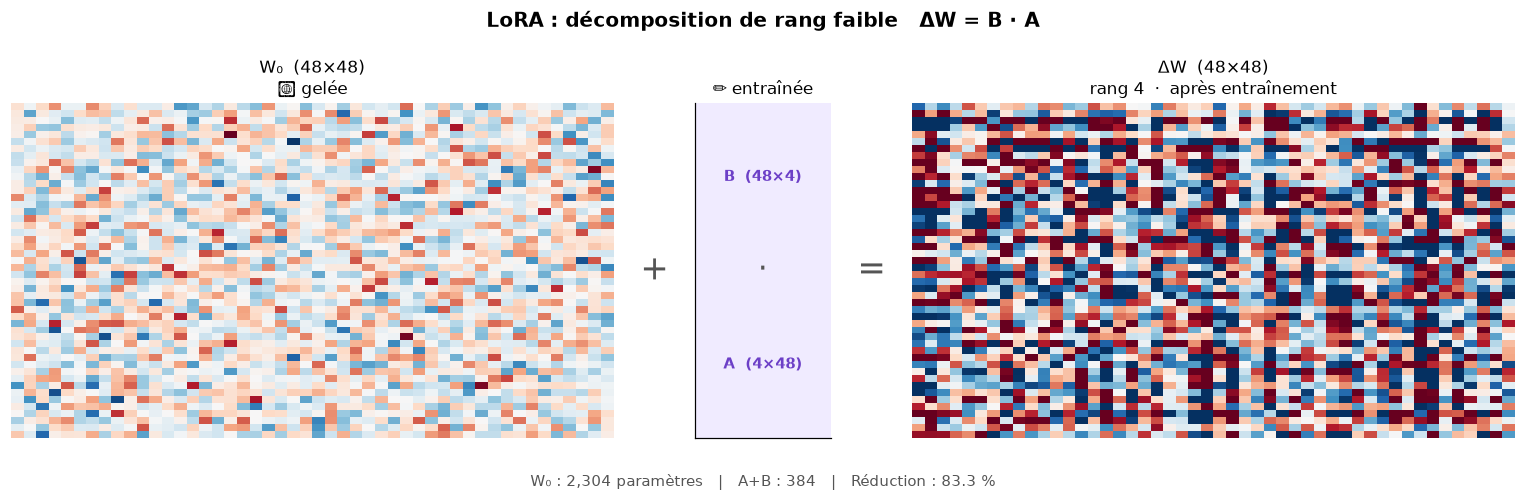

In [5]:
# Visualisation de la décomposition Low-Rank Adaptation (LoRA) :
#   W₀ (gelée) + A·B (entraînable) = ΔW (mise à jour de rang faible)
# d = dimension du modèle, r = rang LoRA (r << d)
fig, axes = plt.subplots(1, 5, figsize=(14, 4.5),
                         gridspec_kw={'width_ratios': [4, 0.3, 0.9, 0.3, 4]})
fig.suptitle("LoRA : décomposition de rang faible   ΔW = B · A",
             fontsize=13, fontweight='bold')

d, r = 48, 4  # valeurs réduites pour la visualisation (modèle réel : d = 4096, r = 8)
np.random.seed(42)
W0 = np.random.randn(d, d) * 0.15   # matrice de poids gelée (simulée)
# Convention du papier LoRA : A est (r × d), B est (d × r), et ΔW = B · A.
# À l'initialisation, B = 0 donc ΔW = 0. On simule ici un état APRÈS entraînement,
# sans quoi le panneau de droite serait uniformément blanc.
A  = np.random.randn(r, d) * 0.5    # première matrice LoRA (r × d)
B  = np.random.randn(d, r) * 0.5    # deuxième matrice LoRA (d × r), nulle à l'init

# Affichage de W₀ : grande matrice carrée, gelée pendant l'entraînement
axes[0].imshow(W0, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
axes[0].set_title(f"W₀  ({d}×{d})\n🔒 gelée", fontsize=11)
axes[0].axis('off')

# Symbole "+"
axes[1].text(0.5, 0.5, '+', fontsize=22, ha='center', va='center',
             transform=axes[1].transAxes, color='#555')
axes[1].axis('off')

# Panneau central : représentation textuelle des matrices A et B (trop étroites pour imshow)
ax_ab = axes[2]
ax_ab.set_facecolor('#f0ebff')
ax_ab.text(0.5, 0.78, f'B  ({d}×{r})', fontsize=10, ha='center', va='center',
           transform=ax_ab.transAxes, fontweight='bold', color='#6c3fc7')
ax_ab.text(0.5, 0.50, '·', fontsize=20, ha='center', va='center',
           transform=ax_ab.transAxes, color='#555')
ax_ab.text(0.5, 0.22, f'A  ({r}×{d})', fontsize=10, ha='center', va='center',
           transform=ax_ab.transAxes, fontweight='bold', color='#6c3fc7')
ax_ab.set_xticks([]); ax_ab.set_yticks([])
ax_ab.set_title("✏️ entraînée", fontsize=11)

# Symbole "="
axes[3].text(0.5, 0.5, '=', fontsize=22, ha='center', va='center',
             transform=axes[3].transAxes, color='#555')
axes[3].axis('off')

# ΔW = B @ A : la mise à jour effective (rang r, beaucoup moins d'info que W₀)
dW = B @ A
axes[4].imshow(dW, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
axes[4].set_title(f"ΔW  ({d}×{d})\nrang {r}  ·  après entraînement", fontsize=11)
axes[4].axis('off')

# Statistiques comparatives en bas de figure
params_full = d * d           # paramètres du full fine-tuning
params_lora = r * d + d * r  # paramètres LoRA = A (r×d) + B (d×r)
reduction   = (1 - params_lora / params_full) * 100
fig.text(0.5, 0.02,
         f"W₀ : {params_full:,} paramètres   |   A+B : {params_lora:,}   |   Réduction : {reduction:.1f} %",
         ha='center', fontsize=10, color='#555')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

> 🎯 **À retenir.** Avec d = 4 096 et r = 8 (les valeurs de Mistral 7B) :
>
> - **Avant Low-Rank Adaptation (LoRA) :** 16 777 216 paramètres entraînables *par matrice de projection adaptée*
> - **Avec Low-Rank Adaptation (LoRA) :** 65 536 paramètres entraînables *pour la même matrice*
> - **Réduction : 99,6 %**, sans perte significative sur les tâches proches du domaine de
>   pré-entraînement. Sur un domaine très éloigné (code, mathématiques), LoRA apprend moins
>   qu'un full fine-tuning, mais il oublie aussi moins. Augmenter `r` et élargir
>   `target_modules` réduit l'écart.
>
> ⚠️ Attention à ne pas confondre : d² est la taille d'**une matrice de projection**, pas d'une
> couche transformer entière, un bloc de Mistral 7B en compte sept, soit ~218 millions de
> paramètres. Et sur les modèles à *Grouped-Query Attention* (Mistral, SmolLM2), `k_proj` et
> `v_proj` sont rectangulaires : leurs adaptateurs sont plus petits que ceux de `q_proj`.
>
> 💡 Bonus : W₀ ne bouge pas → vous pouvez avoir **des dizaines d'adaptateurs Low-Rank Adaptation (LoRA) différents**
> pour un seul modèle de base (un par langue, un par domaine, un par client...).

### 2.3, Quantized Low-Rank Adaptation (QLoRA) : aller encore plus loin avec la quantification

**Le problème restant avec Low-Rank Adaptation (LoRA) seul :** on entraîne peu de paramètres, mais
*W₀ occupe toujours toute la mémoire*. Pour un Mistral 7B distribué en bfloat16 : ~14 Go juste
pour le modèle.

**Quantized Low-Rank Adaptation (QLoRA) combine trois astuces**, pas deux :

1. 🗜️ **Quantifier W₀ en 4-bit NormalFloat4 (NF4)**
   - Au lieu de 16 bits par poids (bfloat16, le format de distribution standard) → **4 bits**
   - Réduction mémoire de **×4** sur W₀ : ~14 Go → ~3,5 Go pour un 7B
   - NF4 est le format 4 bits *information-théoriquement optimal* pour des poids centrés et
     normalement distribués, ce qui décrit bien des poids pré-entraînés. La quantification
     reste **destructrice au niveau des poids** : ce que montre le papier, c'est que la
     **qualité finale du modèle affiné** rejoint celle d'un fine-tuning 16 bits.

2. 🧮 **Double quantification**
   - Les constantes de quantification (une par bloc de 64 poids) sont elles-mêmes quantifiées
   - Gain : ~0,37 bit par paramètre, soit environ 3 Go sur un modèle 65B

3. 📄 **Paged optimizers**
   - Les états de l'optimiseur sont alloués en mémoire unifiée NVIDIA et basculés vers la RAM
     CPU lors des pics. Cela évite les *out-of-memory*, ça ne réduit pas la mémoire en régime établi.

Les adaptateurs LoRA, eux, restent en **bfloat16** : ce qui s'entraîne garde sa précision.
Les gradients traversent les poids NF4 déquantifiés à la volée pour atteindre A et B.

**Résultat :** le papier QLoRA fine-tune un **65B sur un seul GPU de 48 Go** et un **33B sur
24 Go grand public**. Pour un 7B, comptez ~6 Go selon la longueur de séquence.

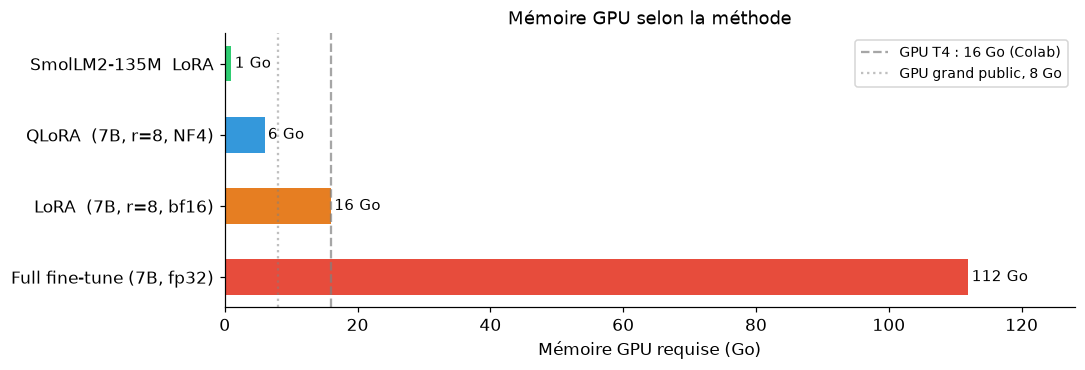

In [6]:
# Comparaison de l'empreinte mémoire GPU selon la méthode de fine-tuning.
# Valeurs approximatives pour un modèle Mistral 7B et SmolLM2-135M.
fig, ax = plt.subplots(figsize=(10, 3.5))

labels   = ['Full fine-tune (7B, fp32)', 'LoRA  (7B, r=8, bf16)', 'QLoRA  (7B, r=8, NF4)', 'SmolLM2-135M  LoRA']
# Go décimaux, mêmes conventions que le tableau de la partie 2.1 :
# full FT = 16 o/param ; LoRA = W₀ en bf16 (14 Go) + activations ; QLoRA = W₀ en NF4 (3,5 Go) + activations.
memoires = [112, 16, 6, 1]                    # en gigaoctets (Go)
couleurs = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']

# Graphique horizontal (barh) : plus lisible pour des libellés longs
barres = ax.barh(labels, memoires, color=couleurs, height=0.5)
ax.set_xlabel('Mémoire GPU requise (Go)')
ax.set_title('Mémoire GPU selon la méthode', fontsize=12)

# Lignes de référence : GPU T4 (Colab gratuit) et GPU grand public typique
ax.axvline(x=16, color='gray', linestyle='--', alpha=0.7, label='GPU T4 : 16 Go (Colab)')
ax.axvline(x=8,  color='gray', linestyle=':',  alpha=0.5, label='GPU grand public, 8 Go')
ax.legend(fontsize=9)

# Étiquettes de valeur au bout de chaque barre
for barre, val in zip(barres, memoires):
    ax.text(val + 0.5, barre.get_y() + barre.get_height() / 2,
            f'{val} Go', va='center', fontsize=10)
ax.set_xlim(0, 128)
plt.tight_layout()
plt.show()

> 🎯 **À retenir.** Quantized Low-Rank Adaptation (QLoRA) = accès au fine-tuning 7B sur du matériel grand public.
> La qualité finale est quasi identique au full fine-tuning sur la plupart des benchmarks.
>
> 🙊 **Note honnête.** La quantification 4-bit nécessite `bitsandbytes`, qui **supporte
> officiellement Windows depuis la version 0.43.0** (avril 2024). Le vrai prérequis n'est pas
> le système mais le matériel : **un GPU NVIDIA avec CUDA**. Pas de quantification 4-bit sur
> CPU ni sur Apple Silicon, d'où Google Colab (gratuit, GPU T4) si vous n'avez pas de carte.

### 2.4, Les paramètres clés de Low-Rank Adaptation (LoRA) et comment lire une courbe de perte

**Les 4 boutons principaux de Low-Rank Adaptation (LoRA) :**

| Paramètre | Ce qu'il contrôle | Valeur recommandée |
|---|---|---|
| `r` | Capacité, ↑ r = plus de puissance, plus de mémoire | **8–16** pour commencer |
| `lora_alpha` | Échelle de la mise à jour (facteur α/r), équivaut à régler le LR des adaptateurs | **r** (défaut PEFT) ou **2 × r** |
| `target_modules` | Quelles couches adapter, commencer petit | `"q_proj", "v_proj"` |
| `lora_dropout` | Régularisation, réduit le sur-entraînement | **0.05–0.1** |

**Comment lire une courbe de perte :**

- ✅ **Entraînement sain** : les deux courbes (train + val) descendent ensemble, puis se stabilisent
- ⚠️ **Sur-entraînement** : la courbe d'entraînement continue de baisser, mais la validation *remonte*
  → le modèle a *mémorisé* les exemples au lieu d'apprendre à généraliser

C:\Users\mickael.labarrere\AppData\Local\Temp\ipykernel_23612\4098320698.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mickael.labarrere\Jura\Formation-Mistral-Public\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


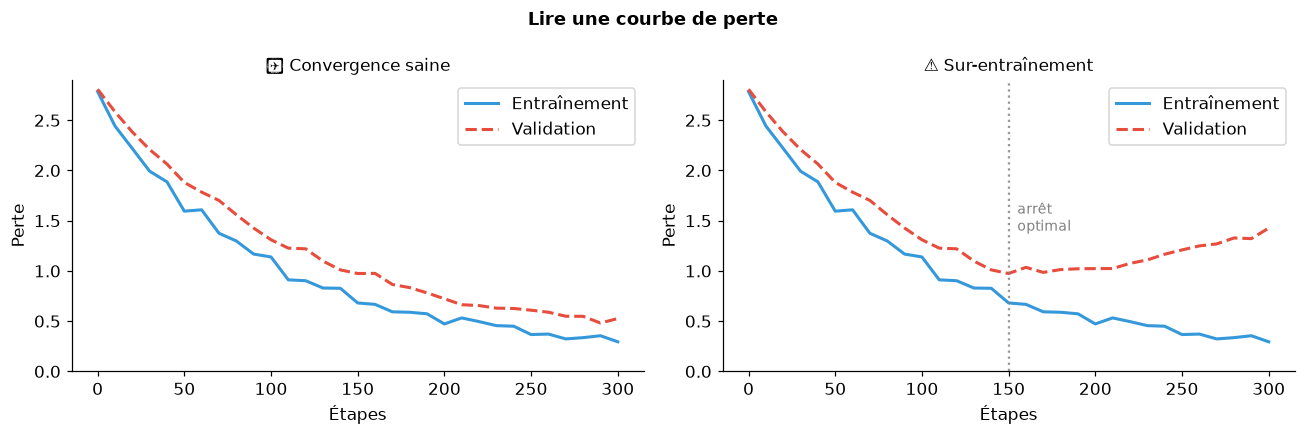

In [7]:
# Simulation de courbes de perte pour illustrer convergence saine vs sur-entraînement.
# Les données sont synthétiques (np.random), objectif : montrer la forme typique.
np.random.seed(1)
etapes = np.arange(0, 310, 10)
t = etapes / 300  # normalise en [0, 1] pour la décroissance exponentielle

# Perte d'entraînement : descente rapide + bruit faible
perte_train   = 2.5 * np.exp(-3.2 * t) + 0.22 + 0.04 * np.random.randn(len(etapes))

# Validation saine : légèrement au-dessus du train, descend en parallèle
perte_val_ok  = 2.5 * np.exp(-2.7 * t) + 0.32 + 0.03 * np.random.randn(len(etapes))
perte_val_ok  = np.maximum(perte_val_ok, perte_train - 0.05)  # val ≥ train (réaliste)

# Validation sur-entraîné : diverge après l'étape 150
perte_val_ko  = perte_val_ok.copy()
perte_val_ko[15:] += np.linspace(0, 0.9, len(etapes) - 15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Trace les deux scénarios côte à côte
for ax, perte_val, titre in [
    (ax1, perte_val_ok, "✅ Convergence saine"),
    (ax2, perte_val_ko, "⚠️ Sur-entraînement"),
]:
    ax.plot(etapes, perte_train, label='Entraînement', color='#3498db', lw=2)
    ax.plot(etapes, perte_val,   label='Validation',   color='#e74c3c', lw=2, linestyle='--')
    ax.set_xlabel('Étapes')
    ax.set_ylabel('Perte')
    ax.set_title(titre, fontsize=11)
    ax.legend()
    ax.set_ylim(0, 2.9)

# Ligne verticale marquant le point d'arrêt optimal dans le cas sur-entraîné
ax2.axvline(x=150, color='gray', linestyle=':', alpha=0.8)
ax2.text(155, 1.4, 'arrêt\noptimal', fontsize=9, color='gray')

plt.suptitle("Lire une courbe de perte", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

> ⚠️ **Piège : le sur-entraînement est fréquent avec peu de données.**
>
> - Si la validation *remonte* → **arrêtez** l'entraînement au point de divergence
> - Avec 100–500 exemples : **1 à 3 epochs max**
> - `save_strategy="epoch"` sauvegarde à chaque epoch, mais ne sélectionne **rien** :
>   pour « récupérer le meilleur checkpoint » il faut un `eval_dataset`, une `eval_strategy`
>   et `load_best_model_at_end=True`. Sans eux, vous obtenez N dossiers et aucun critère.

---
## Partie 3, Mise en œuvre avec SmolLM2-135M

**Pourquoi SmolLM2-135M ?**

- 🪶 **135 millions de paramètres** : le plus petit de la famille SmolLM2, ~270 Mo de poids
- 💬 **Variante Instruct** : déjà entraîné à suivre des instructions, prêt à être fine-tuné
- 🛠️ **Même outillage** qu'un Mistral 7B ou LLaMA 3, tout ce qu'on voit ici s'applique aux grands modèles
- 🏃 Sur GPU dédié, il se fine-tunerait avec Low-Rank Adaptation (LoRA) en **~20 minutes** sur un
  dataset réaliste de quelques centaines d'exemples (avec les 3 exemples de démonstration ci-dessous,
  ce serait affaire de secondes)

> ⚠️ **Les cellules de cette partie sont des références de code.** Chaque cellule concernée
> est marquée **⛔ ne pas exécuter**. Lisez-les, analysez-les, revenez-y sur votre propre GPU.

In [ ]:
# ⛔ ne pas exécuter, télécharge ~270 Mo et autant en RAM (bfloat16, voir ci-dessous).
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct"

# AutoTokenizer : charge le tokenizer adapté au modèle (vocabulaire + chat template)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# dtype="auto" ne détecte PAS le matériel : il reprend le dtype inscrit dans le
# config.json du checkpoint. Pour SmolLM2 c'est bfloat16, y compris sur CPU.
# (L'argument s'appelait torch_dtype jusqu'à transformers 4.56, qui l'a renommé.)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype="auto")

# num_parameters() est l'API Transformers standard
# (préférable à sum(p.numel() for p in model.parameters()))
n_params = model.num_parameters()
print(f"✅ {MODEL_ID}")
print(f"   Paramètres : {n_params:,}")
print(f"   Mémoire (bfloat16) : {n_params * 2 / 1e9:.2f} Go")

> 🎯 **À retenir.** `torch_dtype="auto"` reprend le dtype enregistré dans le `config.json` du
> checkpoint, **ce n'est pas une détection GPU/CPU**. SmolLM2 étant publié en bfloat16, il se
> charge en bfloat16 partout, soit ~270 Mo au lieu des 540 Mo qu'exigerait float32.
>
> ⚠️ Charger en float32 **double** l'empreinte mémoire pour un gain nul en inférence. Pour
> l'**entraînement** en revanche, la pratique standard reste la précision mixte (`bf16=True`) :
> calcul en bfloat16, états d'optimiseur conservés en float32.

### 3.1, Préparer le dataset

**Ce que `SFTTrainer` attend :**
Un objet HuggingFace `Dataset` où chaque ligne contient une clé `messages`
- le même format que l'API Chat, que vous connaissez déjà depuis J1.

**Pourquoi ce format ?** Parce que vos **logs de conversations** vous donnent gratuitement le
format et les vraies questions de vos utilisateurs. Les *réponses*, elles, sont celles de votre
modèle actuel : il faut les filtrer et les corriger avant de les utiliser comme cibles.

Cette cellule **s'exécute librement** : elle ne fait que construire une structure Python en mémoire.

In [8]:
# Conversion de la liste Python en Dataset HuggingFace.
# Dataset.from_list() accepte n'importe quelle liste de dicts, ici nos EXEMPLES_SFT.
# Cette cellule s'exécute librement, aucun GPU, aucun réseau.
from datasets import Dataset

# EXEMPLES_SFT est défini en Partie 1 (cellule t3-p1-sft-code)
dataset = Dataset.from_list(EXEMPLES_SFT)

print(f"✅ Dataset : {len(dataset)} exemples")
print(f"   Colonnes : {dataset.column_names}")  # doit afficher ['messages']
print()

# Aperçu du premier exemple : montre la structure messages[role, content]
print("Premier exemple :")
for msg in dataset[0]["messages"]:
    print(f"  [{msg['role'].upper()}] {msg['content'][:80]}...")

✅ Dataset : 3 exemples
   Colonnes : ['messages']

Premier exemple :
  [USER] Qu'est-ce que le vin jaune du Jura ?...
  [ASSISTANT] Le vin jaune est un vin blanc d'exception produit dans le Jura à partir du cépag...


> ⚠️ **Piège : le mélange de formats.**
> `SFTTrainer` accepte plusieurs formats (`messages`, `prompt`/`completion`, texte brut), mais il
> détecte lequel à partir des **colonnes du dataset**, pas ligne par ligne. Un dataset hétérogène
> produit soit une erreur obscure au moment d'appliquer le chat template, soit un entraînement
> sur des données mal formatées.
>
> ✅ **Solution :** choisir un format unique dès le début. Le format `messages` est le plus polyvalent.

### 3.2, Configurer Low-Rank Adaptation (LoRA) avec Parameter-Efficient Fine-Tuning (PEFT)

**Deux étapes pour activer Low-Rank Adaptation (LoRA) :**

1. 📋 **Créer un `LoraConfig`** : déclarer le rang, les couches cibles, et le facteur d'échelle
2. 🔧 **Appeler `get_peft_model(model, config)`** : injecter les adaptateurs et geler W₀

**Ce que fait `get_peft_model` en coulisses :**
- ❄️ *Gèle* tous les paramètres du modèle (`requires_grad = False`)
- ➕ *Ajoute* les matrices A et B de Low-Rank Adaptation (LoRA) aux couches ciblées (`requires_grad = True`)
- 📊 *Affiche* le ratio paramètres entraînables / total

In [ ]:
# ⛔ ne pas exécuter, nécessite que `model` soit chargé (cellule précédente).
from peft import LoraConfig, get_peft_model, TaskType

# LoraConfig déclare l'architecture des adaptateurs : rang, couches cibles, régularisation
config_lora = LoraConfig(
    task_type=TaskType.CAUSAL_LM,        # type de tâche : génération de texte autoregressive
    r=8,                                  # rang, bon compromis capacité / mémoire
    lora_alpha=16,                        # facteur d'échelle : α/r = 2 (un choix courant, pas une règle)
    target_modules=["q_proj", "v_proj"],  # on adapte query et value des têtes d'attention
    lora_dropout=0.05,                    # dropout sur A·B pour réduire le sur-entraînement
    bias="none",                          # ne pas ajouter de biais LoRA (recommandé)
)

# get_peft_model : gèle tous les poids W₀ (requires_grad=False),
# injecte les matrices A et B dans les couches ciblées (requires_grad=True).
# ⚠️ L'injection se fait SUR PLACE dans `model`, ce n'est pas une copie. Ré-exécuter
# cette cellule empile un second jeu d'adaptateurs et fausse le décompte.
model_lora = get_peft_model(model, config_lora)
model_lora.print_trainable_parameters()
# → trainable params: 460,800 || all params: 134,975,808 || trainable%: 0.3414
#   (576 dims × 30 couches ; v_proj ne fait que 576×192 car SmolLM2 utilise
#    la Grouped-Query Attention : 3 têtes KV pour 9 têtes de requête)

> 🎯 **À retenir.** Sur SmolLM2-135M avec Low-Rank Adaptation (LoRA) r=8 :
>
> - 🔢 **460 800 paramètres entraînables** sur 134 975 808 au total → **0,34 % seulement**
> - 💾 États de l'optimiseur : de **1,08 Go** (full fine-tuning) à **3,7 Mo** (LoRA)
> - ⚡ Entraînement **~25 % plus rapide** (chiffre du papier LoRA sur GPT-3 175B), et surtout
>   **~3× moins de mémoire GPU**
>
> ⚠️ Ne pas se tromper sur ce que LoRA économise : les poids gelés W₀ (~270 Mo en bfloat16) et
> les activations **restent en mémoire**. Ce qui disparaît, ce sont les gradients et les états
> d'optimiseur *du modèle de base*.

### 3.3, Lancer l'entraînement avec SFTTrainer (Supervised Fine-Tuning Trainer)

**`SFTTrainer` = la boucle de Supervised Fine-Tuning (SFT) clé en main.** En quelques lignes, il gère :

- 📦 Le **batching** et le padding des séquences
- 🔄 Le **gradient accumulation** pour simuler de grands batchs sur peu de mémoire
- 📈 Le **learning rate scheduler** (montée progressive + descente en cosinus)
- 💾 La **sauvegarde** du modèle à chaque epoch
- 📊 Le **logging** (compatible Weights & Biases, TensorBoard)

**Les paramètres clés à comprendre :**

| Paramètre | Rôle | Valeur ici |
|---|---|---|
| `num_train_epochs` | Passages complets sur le dataset | **3** (1–5 max pour SFT) |
| `per_device_train_batch_size` | Exemples en mémoire en même temps | **4** |
| `gradient_accumulation_steps` | Batchs accumulés avant une update | **4** → batch effectif = 16 |
| `learning_rate` | Vitesse d'apprentissage | **2e-4** (plus élevé qu'un full fine-tuning) |
| `lr_scheduler_type` | Comment le LR évolue dans le temps | **cosine** (recommandé) |
| `max_seq_length` | Longueur max des séquences en tokens | **512** |

In [ ]:
# ⛔ ne pas exécuter : construit le trainer, `trainer.train()` reste commenté plus bas.
# Les hyperparamètres ci-dessous sont dimensionnés pour un dataset réaliste (~500 exemples,
# ~20 min sur GPU T4). Avec les 3 exemples de démonstration, le batch effectif de 16 dépasse
# le dataset entier : l'entraînement durerait quelques secondes et logging_steps=10 ne
# déclencherait jamais un seul affichage.
from trl import SFTTrainer, SFTConfig

# SFTConfig regroupe tous les hyperparamètres d'entraînement
# (remplace TrainingArguments pour le Supervised Fine-Tuning depuis trl 0.9)
training_args = SFTConfig(
    output_dir="./smollm2-jura-ft",        # dossier de sauvegarde des checkpoints
    num_train_epochs=3,                     # 3 passages sur le dataset (1–5 max en SFT)
    per_device_train_batch_size=4,          # exemples traités par GPU à chaque étape
    gradient_accumulation_steps=4,          # accumule 4 batchs → batch effectif = 4×4 = 16
                                            # ⚠️ plafonné par la taille du dataset : 3 ici
    learning_rate=2e-4,                     # LR plus élevé qu'un full FT (LoRA le tolère)
    lr_scheduler_type="cosine",             # LR décroissant en cosinus jusqu'à 0 en fin d'entraînement
    warmup_ratio=0.1,                       # 10 % des étapes en montée progressive du LR
                                            # ⚠️ sur les 3 pas de ce dataset, ceil(3×0.1) = 1,
                                            # soit 33 % de warmup : mettre 0.0 à cette échelle
    logging_steps=10,                       # affiche la perte toutes les 10 étapes
                                            # ⚠️ avec 3 pas au total, aucune ligne ne sortira :
                                            # mettre 1 pour voir quelque chose sur ce dataset
    save_strategy="epoch",                  # le modèle étant un PeftModel, seul l'ADAPTATEUR
                                            # est sauvegardé (~1,8 Mio), pas le modèle entier
    bf16=False,                             # True sur GPU Ampere ou plus récent (RTX 30xx/40xx, A10, A100, H100)
                                            # ⚠️ sur T4 (Turing), bf16 n'existe pas : utiliser fp16=True
    report_to="none",                       # désactive W&B / TensorBoard pour cet exemple
    max_length=512,                         # tronque les exemples dépassant 512 tokens
                                            # ⚠️ s'appelait `max_seq_length` avant trl 0.20,
                                            # où l'ancien nom a été SUPPRIMÉ → TypeError
)

# SFTTrainer orchestre la boucle complète : tokenisation, padding, gradient accumulation,
# application du chat template et sauvegarde automatique des checkpoints
trainer = SFTTrainer(
    model=model_lora,
    args=training_args,
    train_dataset=dataset,
    processing_class=tokenizer,             # `tokenizer=` est déprécié depuis trl 0.12
)

# trainer.train()  # ← décommenter uniquement sur GPU dédié

> 🎯 **À retenir : l'astuce du gradient accumulation.**
>
> - ❌ Batch de 16 en une fois → **crash** out-of-memory sur un petit GPU
> - ✅ 4 batchs de 4 accumulés → **résultat quasi identique**, avec **4× moins d'activations**
>   en mémoire. Les poids, les gradients et les états d'optimiseur, eux, ne bougent pas : la
>   mémoire totale n'est donc pas divisée par 4.
>
> C'est l'un des paramètres les plus importants pour le Supervised Fine-Tuning (SFT) sur du matériel limité.
>
> ⚠️ L'équivalence n'est exacte que si la perte est normalisée sur le **nombre total de tokens**
> de l'accumulation, et non moyennée par micro-batch. C'est précisément le bug corrigé dans
> `transformers` fin 2024 : utilisez une version récente.

> 🙊 **Note honnête.** `SFTTrainer` gère le **chat template** automatiquement si le tokenizer
> le définit. SmolLM2-Instruct le fait nativement. Avec d'autres modèles → **vérifiez toujours** :
> un mauvais template produit un modèle inutilisable sans aucune erreur visible.

> ⚠️ **Le piège qu'on ne voit pas venir : par défaut, la perte porte sur la séquence entière.**
> Sur un dataset conversationnel, le modèle est donc entraîné à générer *aussi la question de
> l'utilisateur*, pas seulement la réponse. Pour ne l'entraîner que sur la réponse, il faut
> `assistant_only_loss=True`, ce qui exige un `chat_template` contenant un bloc
> `{% generation %}` pour délimiter la réponse, et **SmolLM2 n'en a pas**. À l'échelle de ce
> notebook c'est sans conséquence ; sur un vrai projet, c'est la première chose à vérifier.

### 3.4, Estimer le coût avant de lancer

**La formule de base :**

```
Coût = (nb d'exemples × tokens par exemple × epochs) / 1 000 000 × prix par million
```

- 📏 **Tokens par exemple** : longueur moyenne de vos paires (question + réponse)
- 🔄 **Epochs** : 1 à 3 avec moins de 1 000 exemples, 2 à 4 au-delà. Surveillez la courbe de
  validation plutôt que de fixer un nombre à l'avance.
- 💰 **Prix Mistral Fine-tuning API** : ~2 $ / million de tokens *(vérifier le tarif du modèle visé)*
- ⚠️ **Et surtout le minimum facturé** : tout job de fine-tuning coûte au moins **4 $**, plus
  **2 $ par mois** de stockage du modèle affiné. En dessous de 2 millions de tokens, c'est le
  minimum qui décide de la facture, pas la formule.

Cette cellule **s'exécute librement** : aucun GPU, aucun réseau.

In [9]:
# Estimation du coût de fine-tuning via l'API Mistral.
# Formule : (exemples × tokens_par_exemple × epochs) / 1 000 000 × prix_par_million
# Cette cellule s'exécute librement.
PRIX_PAR_MILLION  = 2.0  # tarif Mistral fine-tuning en USD (vérifier le tarif du modèle visé)
MINIMUM_PAR_JOB   = 4.0  # tout job est facturé au moins 4 $
STOCKAGE_MENSUEL  = 2.0  # 2 $/mois de stockage par modèle affiné

# (label, nb_exemples, tokens_par_exemple, epochs)
scenarios = [
    ("Dataset Jura (3 ex.)", 3,      160,  3),   # ~160 tokens/ex., mesuré sur EXEMPLES_SFT
    ("Projet pilote",        500,    1024, 3),
    ("Production courante",  5_000,  512,  1),
    ("Grand dataset",        50_000, 256,  3),
]

# Tableau Rich : colonne USD en vert pour attirer l'œil sur le coût
table = Table(title=f"Estimation de coût fine-tuning (API Mistral · {PRIX_PAR_MILLION} $/M tokens)")
table.add_column("Scénario",      style="cyan")
table.add_column("Exemples",      justify="right")
table.add_column("Tokens total",  justify="right")
table.add_column("Coût tokens",   justify="right")
table.add_column("Facturé",       justify="right", style="green")

for label, n_ex, tok, ep in scenarios:
    tokens  = n_ex * tok * ep                       # tokens totaux consommés
    calcul  = tokens / 1_000_000 * PRIX_PAR_MILLION # coût au token
    # Le minimum de 4 $ par job domine tant que le dataset reste petit ;
    # les 2 $ de stockage mensuel s'ajoutent dans tous les cas.
    usd     = max(calcul, MINIMUM_PAR_JOB) + STOCKAGE_MENSUEL
    table.add_row(label, f"{n_ex:,}", f"{tokens:,}", f"${calcul:.2f}", f"${usd:.2f}")

Console().print(table)
print("💡 100–300 exemples pour valider le pipeline, 300–1 000 pour un résultat exploitable.")
print("   En dessous de 2 M tokens, c'est le minimum de 4 $ qui fixe la facture.")

      Estimation de coût fine-tuning (API Mistral · 2.0 $/M tokens)       
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Scénario             ┃ Exemples ┃ Tokens total ┃ Coût tokens ┃ Facturé ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━┩
│ Dataset Jura (3 ex.) │        3 │        1,440 │       $0.00 │   $6.00 │
│ Projet pilote        │      500 │    1,536,000 │       $3.07 │   $6.00 │
│ Production courante  │    5,000 │    2,560,000 │       $5.12 │   $7.12 │
│ Grand dataset        │   50,000 │   38,400,000 │      $76.80 │  $78.80 │
└──────────────────────┴──────────┴──────────────┴─────────────┴─────────┘

💡 100–300 exemples pour valider le pipeline, 300–1 000 pour un résultat exploitable.
   En dessous de 2 M tokens, c'est le minimum de 4 $ qui fixe la facture.


> 🎯 **À retenir.** Le coût au token est **proportionnel aux tokens × epochs**, mais tant que
> le dataset est petit, c'est le **minimum de 4 $ par job** qui décide. Un dataset de
> 500 exemples (~1 000 tokens chacun) revient à 3,07 $ de calcul, donc **6 $ facturés**
> (4 $ de minimum + 2 $ de stockage mensuel).
>
> 💡 Le vrai coût d'un SFT, c'est **la curation des données** (temps humain),
> pas le calcul. Un exemple mal annoté coûte plus qu'il ne rapporte.

### 3.5, Évaluer le modèle affiné

⚠️ **Un modèle qui minimise la perte n'est pas forcément utile en pratique.**

**3 niveaux d'évaluation, du plus rapide au plus rigoureux :**

1. 🏃 **Évaluation humaine rapide** : *à faire en premier, toujours*
   - Testez sur 20–30 exemples manuellement
   - Détecte les régressions évidentes en 30 minutes
   - Aucun outil nécessaire

2. 📊 **Métriques automatiques** : *confirmation à grande échelle*
   - ROUGE-L : recouvrement de séquences avec les réponses de référence
   - BERTScore : similarité sémantique entre réponses générées et références
   - Perplexité : à quel point le modèle prédit bien le texte de référence (↓ = mieux).
     À ne comparer qu'entre variantes du **même** modèle et du **même** format de données.

3. 🤖 **LLM-as-judge** : *évaluation sémantique sans référence humaine*
   - Un LLM juge (Mistral Large, Claude, GPT-4o…) compare la réponse du modèle affiné vs la baseline
   - Utile quand les réponses correctes ont plusieurs formes valides
   - Coût : quelques millièmes de dollar par comparaison, selon le modèle et la longueur des réponses

In [10]:
# Tableau récapitulatif des métriques d'évaluation d'un modèle fine-tuné.
# Sens "↓" = plus bas est mieux, "↑" = plus haut est mieux.
# Cette cellule s'exécute librement.
metriques = [
    ("Perplexité",      "↓", "Qualité de prédiction du texte de référence. Non comparable entre modèles."),
    ("ROUGE-L",         "↑", "Recouvrement de séquences avec les réponses de référence."),
    ("BERTScore",       "↑", "Similarité sémantique entre réponses générées et références."),
    ("Win rate (LLM)",  "↑", "% de fois où le modèle affiné bat la baseline, jugé par un LLM juge."),
    ("Éval. humaine",   "↑", "Notation manuelle sur 20–50 exemples. Le gold standard."),
]

# Tableau Rich : colonne "Sens" centrée pour faciliter la lecture rapide
table = Table(title="Métriques d'évaluation d'un modèle fine-tuné")
table.add_column("Métrique",    style="cyan")
table.add_column("Sens",        justify="center")
table.add_column("Description")

for nom, sens, desc in metriques:
    table.add_row(nom, sens, desc)

Console().print(table)
print("\n💡 Commencez par une évaluation humaine sur 20 exemples.")
print("   Les métriques automatiques confirment, elles ne remplacent pas le jugement.")

                             Métriques d'évaluation d'un modèle fine-tuné                             
┏━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Métrique       ┃ Sens ┃ Description                                                                ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Perplexité     │  ↓   │ Qualité de prédiction du texte de référence. Non comparable entre modèles. │
│ ROUGE-L        │  ↑   │ Recouvrement de séquences avec les réponses de référence.                  │
│ BERTScore      │  ↑   │ Similarité sémantique entre réponses générées et références.               │
│ Win rate (LLM) │  ↑   │ % de fois où le modèle affiné bat la baseline, jugé par un LLM juge.       │
│ Éval. humaine  │  ↑   │ Notation manuelle sur 20–50 exemples. Le gold standard.                    │
└────────────────┴──────┴────────────────────────────────────────────────────────────────────────────┘


💡 Commencez par une évaluation humaine sur 20 exemples.
   Les métriques automatiques confirment, elles ne remplacent pas le jugement.


> 🙊 **Note honnête : le catastrophic forgetting.**
> Un modèle fine-tuné peut **régresser** sur des tâches hors de sa distribution d'entraînement.
> Si vous fine-tunez sur des recettes de cuisine, il risque de moins bien faire les maths.
>
> ✅ **Solution :** toujours évaluer sur un benchmark **généraliste** *en plus* de votre benchmark spécialisé.

---
## 🔭 Pour aller plus loin

- 🚀 **[Unsloth](https://github.com/unslothai/unsloth)** : noyaux Triton optimisés, ~2× plus rapide et nettement moins gourmand en VRAM. Le `SFTTrainer` de TRL reste inchangé, mais le chargement du modèle doit passer par `FastLanguageModel.from_pretrained()`
- 🔧 **[Axolotl](https://github.com/axolotl-ai-cloud/axolotl)** : fine-tuner n'importe quel modèle HuggingFace via un simple fichier de config YAML
- ⚡ **[ORPO](https://arxiv.org/abs/2403.07691)** : combine la perte SFT et un terme de préférence par rapport de cotes (*odds ratio*) en *une seule passe*, sans modèle de référence séparé
- ☁️ **[Mistral Fine-tuning API](https://docs.mistral.ai/capabilities/finetuning/)** : fine-tuner sans GPU, en quelques appels API, avec suivi des jobs

---
## 📚 Ressources

### Documentation officielle

| Outil | Lien |
|---|---|
| HuggingFace Transformers | [huggingface.co/docs/transformers](https://huggingface.co/docs/transformers) |
| HuggingFace TRL (SFT, DPO, RLHF) | [huggingface.co/docs/trl](https://huggingface.co/docs/trl) |
| HuggingFace PEFT (LoRA, QLoRA) | [huggingface.co/docs/peft](https://huggingface.co/docs/peft) |
| HuggingFace Datasets | [huggingface.co/docs/datasets](https://huggingface.co/docs/datasets) |
| Mistral, Fine-tuning API | [docs.mistral.ai/capabilities/finetuning](https://docs.mistral.ai/capabilities/finetuning/) |
| SmolLM2-135M-Instruct (model card) | [huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct) |

### Articles académiques

| Article | Lien |
|---|---|
| **LoRA** : Hu et al., 2021 | [arxiv.org/abs/2106.09685](https://arxiv.org/abs/2106.09685) |
| **QLoRA** : Dettmers et al., 2023 | [arxiv.org/abs/2305.14314](https://arxiv.org/abs/2305.14314) |
| **DPO** : Rafailov et al., 2023 | [arxiv.org/abs/2305.18290](https://arxiv.org/abs/2305.18290) |
| **ORPO** : Hong et al., 2024 | [arxiv.org/abs/2403.07691](https://arxiv.org/abs/2403.07691) |
| **InstructGPT** (RLHF), Ouyang et al., 2022 | [arxiv.org/abs/2203.02155](https://arxiv.org/abs/2203.02155) |

### Tutoriels et guides

- [HuggingFace, Fine-tuning LLM avec TRL (tutoriel officiel)](https://huggingface.co/docs/trl/tutorials/sft_finetuning)
- [HuggingFace blog, RLHF expliqué](https://huggingface.co/blog/rlhf)
- [HuggingFace blog, SmolLM2 (annonce + benchmarks)](https://huggingface.co/blog/smollm2)
- [Mistral blog, Guide fine-tuning](https://mistral.ai/news/fine-tuning/)